# Griffiths Problem 1.50 & Theorems 1/2: The Full Equivalence Chains

Problem 1.50 gives three fields that span all three regions of the
irrotational/solenoidal Venn diagram:

| field | $\nabla\cdot F$ | $\nabla\times F$ | has scalar potential? | has vector potential? |
|---|---|---|---|---|
| $F_1=x^2\hat z$ | 0 | $-2x\hat y$ | no | yes |
| $F_2=x\hat x+y\hat y+z\hat z$ | 3 | 0 | yes | no |
| $F_3=yz\hat x+xz\hat y+xy\hat z$ | 0 | 0 | yes | yes |

Theorems 1 and 2 each state FOUR equivalent conditions (a)-(d). This
notebook doesn't stop at proving (d) (finding the potential) -- it checks
(b) and (c) too, directly, with real numerical quadrature: closed-loop /
path-independence for $F_2$ (the purely irrotational field), and
closed-surface / surface-independence for $F_1$ (the purely solenoidal
field). Plus the two generic identities (Eq 1.44, 1.46) Problems 1.51(d)
and 1.52(d) invoke, proven for an UNDEFINED scalar/vector function, not a
specific example. Engine: `dgs/griffiths_1p50_theorems_polyglot.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from dgs import griffiths_1p50_theorems_polyglot as g150

sp.init_printing()
print('Setup complete.')


Setup complete.


## 1. Problem 1.50: All Three Fields


In [2]:
p1 = g150.field_F1_properties()
print('F1 = x^2*zhat  (purely solenoidal):')
display(Math(r'\nabla\cdot F_1 = ' + sp.latex(p1['div_F1'])))
display(Math(r'\nabla\times F_1 = ' + sp.latex(p1['curl_F1'])))
display(Math(r'A_1 = ' + sp.latex(p1['vector_potential_A1'])))
print(f"curl(A1) == F1: {p1['curl_A1_matches_F1']}")


F1 = x^2*zhat  (purely solenoidal):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

curl(A1) == F1: True


In [3]:
p2 = g150.field_F2_properties()
print('F2 = x*xhat+y*yhat+z*zhat = r  (purely irrotational):')
display(Math(r'\nabla\cdot F_2 = ' + sp.latex(p2['div_F2'])))
print(f"curl(F2) == 0: {p2['curl_F2_is_zero']}")
display(Math(r'V_2 = ' + sp.latex(p2['scalar_potential_V2'])))
print(f"-grad(V2) == F2: {p2['minus_grad_V2_matches_F2']}")


F2 = x*xhat+y*yhat+z*zhat = r  (purely irrotational):


<IPython.core.display.Math object>

curl(F2) == 0: True


<IPython.core.display.Math object>

-grad(V2) == F2: True


In [4]:
p3 = g150.field_F3_properties()
print('F3 = yz*xhat+xz*yhat+xy*zhat  (BOTH irrotational and solenoidal):')
print(f"div(F3) == 0: {p3['div_F3']==0}, curl(F3) == 0: {p3['curl_F3_is_zero']}")
display(Math(r'U_3 = ' + sp.latex(p3['scalar_potential_U3'])))
print(f"grad(U3) == F3: {p3['grad_U3_matches_F3']}")
display(Math(r'A_3 = ' + sp.latex(p3['vector_potential_A3'])))
print(f"curl(A3) == F3: {p3['curl_A3_matches_F3']}")


F3 = yz*xhat+xz*yhat+xy*zhat  (BOTH irrotational and solenoidal):
div(F3) == 0: True, curl(F3) == 0: True


<IPython.core.display.Math object>

grad(U3) == F3: True


<IPython.core.display.Math object>

curl(A3) == F3: True


## 2. The Two Generic Identities (Problems 1.51(d), 1.52(d))

$\nabla\times(\nabla f)=0$ and $\nabla\cdot(\nabla\times\mathbf A)=0$, proven
for an UNDEFINED function `f`/`A` (SymPy `Function`, not a concrete
formula) -- these are what make (d)$\Rightarrow$(a) work for EVERY field
with a potential, not just the three above.


In [5]:
from sympy.vector import CoordSys3D, curl as sp_curl, divergence as sp_div, gradient as sp_grad

_N = CoordSys3D('N')
_x, _y, _z = _N.x, _N.y, _N.z

f_generic = sp.Function('f')(_x, _y, _z)
curl_grad_f = sp_curl(sp_grad(f_generic))
display(Math(r'\nabla\times(\nabla f) = ' + sp.latex(curl_grad_f)))

Ax, Ay, Az = (sp.Function(name)(_x, _y, _z) for name in ('A_x', 'A_y', 'A_z'))
A_generic = Ax*_N.i + Ay*_N.j + Az*_N.k
div_curl_A = sp.simplify(sp_div(sp_curl(A_generic)))
display(Math(r'\nabla\cdot(\nabla\times\mathbf{A}) = ' + sp.latex(div_curl_A)))

print('curl(grad f) = 0 for a generic f:', g150.curl_of_gradient_is_zero_generic())
print('div(curl A) = 0 for a generic A:  ', g150.divergence_of_curl_is_zero_generic())


<IPython.core.display.Math object>

<IPython.core.display.Math object>

curl(grad f) = 0 for a generic f: True
div(curl A) = 0 for a generic A:   True


## 3. Theorem 1, Instantiated on $F_2$ (Irrotational)

**(c)**: $\oint F_2\cdot d\boldsymbol\ell=0$ around a closed loop.
**(b)**: $\int_a^b F_2\cdot d\boldsymbol\ell$ is the same along two
different paths. Both checked on a genuinely non-planar loop/path pair
(not one that's trivially zero by flat symmetry).


In [6]:
loop = [(0, 0, 0), (1, 0, 0), (1, 1, 1), (0, 1, 0), (0, 0, 0)]
circ = g150.closed_loop_line_integral_F2(loop)
print(f'(c) closed-loop integral (non-planar loop): {circ:.3e}   (expect 0)')

paths = g150.two_path_independence_F2((0, 0, 0), (1, 1, 1), (1, 0, 0), (0, 1, 0))
print(f"(b) path I: {paths['integral_path_I']:.6f}, path II: {paths['integral_path_II']:.6f}, "
      f"diff: {paths['abs_diff']:.3e}")


(c) closed-loop integral (non-planar loop): -2.220e-16   (expect 0)
(b) path I: 1.500000, path II: 1.500000, diff: 0.000e+00


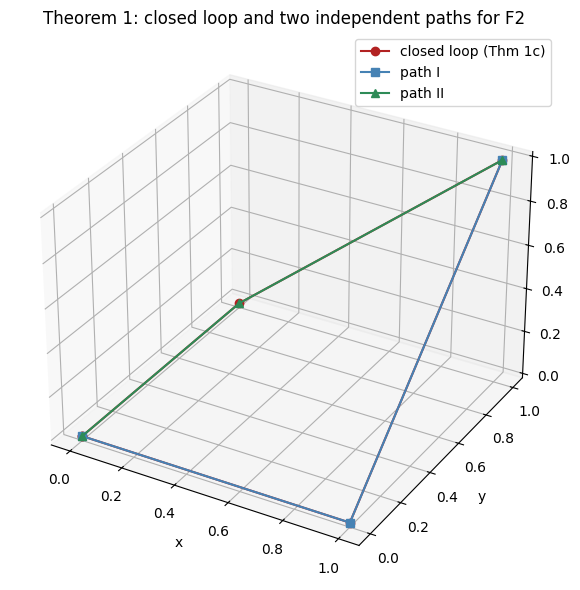

In [7]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection='3d')
loop_arr = np.array(loop)
ax.plot(loop_arr[:, 0], loop_arr[:, 1], loop_arr[:, 2], 'o-', color='firebrick', label='closed loop (Thm 1c)')
path_I = np.array([(0, 0, 0), (1, 0, 0), (1, 1, 1)])
path_II = np.array([(0, 0, 0), (0, 1, 0), (1, 1, 1)])
ax.plot(path_I[:, 0], path_I[:, 1], path_I[:, 2], 's-', color='steelblue', label='path I')
ax.plot(path_II[:, 0], path_II[:, 1], path_II[:, 2], '^-', color='seagreen', label='path II')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Theorem 1: closed loop and two independent paths for F2')
ax.legend()
plt.tight_layout()
plt.savefig('griffiths_1p50_theorem1_paths.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Theorem 2, Instantiated on $F_1$ (Solenoidal)

**(c)**: $\oint F_1\cdot d\mathbf a=0$ over a closed surface (the unit
cube). **(b)**: $\int F_1\cdot d\mathbf a$ is the same over two different
OPEN surfaces sharing one boundary loop -- a flat patch and a sinusoidal
"bump," both using a consistent "upward" orientation (avoiding the
outward/inward sign flip Griffiths' own Problem 1.52 solution flags for
closed-surface splitting).


In [8]:
flux = g150.closed_cube_surface_flux_F1()
print(f'(c) closed-surface flux (unit cube, outward normals): {flux:.3e}   (expect 0)')

surfaces = g150.two_surface_independence_F1()
print(f"(b) flat surface flux: {surfaces['flat_surface_flux']:.6f}, "
      f"bump surface flux: {surfaces['bump_surface_flux']:.6f}, diff: {surfaces['abs_diff']:.3e}")


(c) closed-surface flux (unit cube, outward normals): 0.000e+00   (expect 0)
(b) flat surface flux: 0.333333, bump surface flux: 0.333333, diff: 0.000e+00


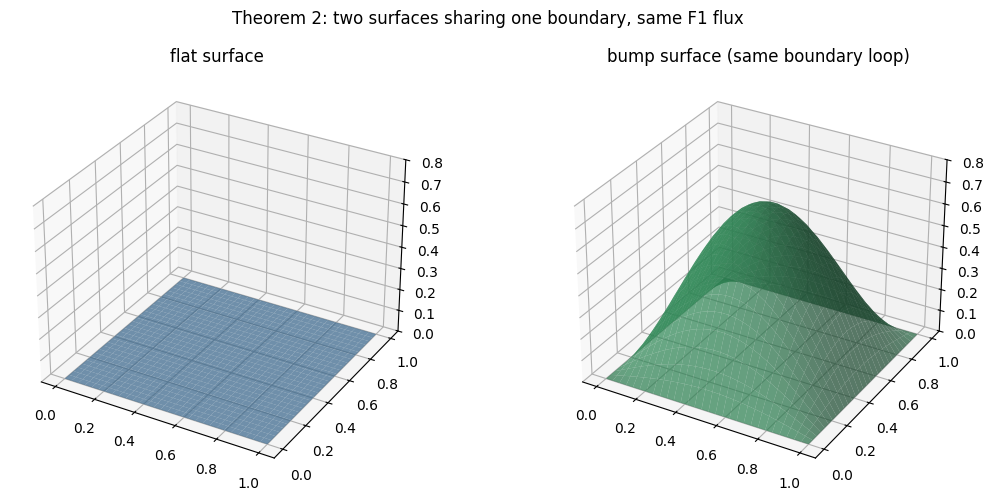

In [9]:
fig = plt.figure(figsize=(11, 5))
u = np.linspace(0, 1, 30)
U, V = np.meshgrid(u, u)

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(U, V, np.zeros_like(U), alpha=0.7, color='steelblue')
ax1.set_title('flat surface')
ax1.set_zlim(0, 0.8)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
h = 0.7
Z_bump = h * np.sin(np.pi * U) * np.sin(np.pi * V)
ax2.plot_surface(U, V, Z_bump, alpha=0.7, color='seagreen')
ax2.set_title('bump surface (same boundary loop)')
ax2.set_zlim(0, 0.8)

plt.suptitle('Theorem 2: two surfaces sharing one boundary, same F1 flux')
plt.tight_layout()
plt.savefig('griffiths_1p50_theorem2_surfaces.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. PyTorch Cross-Check

Autograd-exact divergence/curl (via `torch.func.jacrev`+`vmap`) of all
three fields, independent of the SymPy derivation.


In [10]:
try:
    import torch
    rng = np.random.default_rng(0)
    pts = rng.uniform(-2, 2, size=(50, 3))
    for name in ('F1', 'F2', 'F3'):
        t = g150.torch_div_curl(name, pts)
        print(f"{name}: max|div|={np.max(np.abs(t['divergence'])):.3e}, max|curl|={np.max(np.abs(t['curl'])):.3e}")
except ImportError:
    print('torch not available in this kernel -- run under py 3.12 for this section')


F1: max|div|=0.000e+00, max|curl|=3.868e+00
F2: max|div|=3.000e+00, max|curl|=0.000e+00
F3: max|div|=0.000e+00, max|curl|=0.000e+00


## 6. MATLAB Cross-Check and "Time of Solving"

MATLAB has no Symbolic Math Toolbox on this machine (checked directly),
so `run_matlab_1p50_check` does the same job as the torch section --
finite-difference divergence/curl at one test point -- independently
coded from scratch in MATLAB, run headless via `matlab -batch`.

`benchmark_solve_times` then times each tool actually "solving" Problem
1.50: SymPy does the full EXACT symbolic job (div, curl, and verifying
every potential, for all three fields); torch does the numerical
autograd-exact div/curl at a batch of sample points; MATLAB does the
numerical finite-difference version via a fresh subprocess launch. The
MATLAB timing INCLUDES the `matlab -batch` process-startup cost -- a real,
substantial, honestly-reported overhead, not excluded to make the
comparison look fairer.


In [11]:
import os

HAVE_MATLAB = os.path.exists(g150.MATLAB_DEFAULT)
if HAVE_MATLAB:
    import tempfile
    with tempfile.TemporaryDirectory() as tmp:
        matlab_result = g150.run_matlab_1p50_check(tmp)
    for name in ('F1', 'F2', 'F3'):
        r = matlab_result[name]
        print(f"{name}: div={r['divergence']:.6f}, curl={r['curl']}")
else:
    print('MATLAB not found at', g150.MATLAB_DEFAULT, '-- section skipped')


F1: div=0.000000, curl=[ 0.  -2.6  0. ]
F2: div=3.000000, curl=[0. 0. 0.]
F3: div=0.000000, curl=[-2.77555756e-10 -2.77555756e-10 -2.22044605e-10]


   sympy_seconds:     20.35 ms
   torch_seconds:      2.07 ms
  matlab_seconds:   2629.95 ms


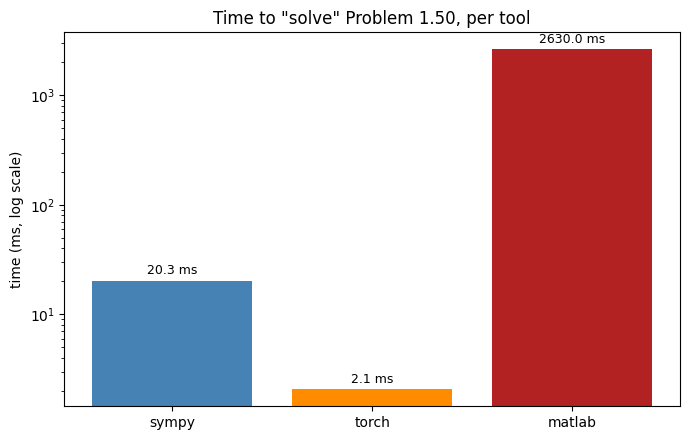

In [12]:
if HAVE_MATLAB:
    times = g150.benchmark_solve_times(run_matlab=True)
    for tool, seconds in times.items():
        print(f'{tool:>16}: {seconds*1000:>9.2f} ms')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    tools = [t.replace('_seconds', '') for t in times.keys()]
    values_ms = [v * 1000 for v in times.values()]
    colors = ['steelblue', 'darkorange', 'firebrick']
    ax.bar(tools, values_ms, color=colors[:len(tools)])
    ax.set_ylabel('time (ms, log scale)')
    ax.set_yscale('log')
    ax.set_title('Time to "solve" Problem 1.50, per tool')
    for i, v in enumerate(values_ms):
        ax.text(i, v * 1.15, f'{v:.1f} ms', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('griffiths_1p50_timing_benchmark.png', dpi=100, bbox_inches='tight')
    plt.show()


## 7. Engineering Interpretation

- The Venn-diagram table in Section 1 is the actual payoff of using THREE
  fields instead of one: $F_1$ and $F_2$ each satisfy exactly one theorem
  (and each theorem's necessary potential DOESN'T exist for the field it
  doesn't apply to -- $F_2$ genuinely has no vector potential, not just
  "one wasn't found"), while $F_3$ satisfies both simultaneously, showing
  the two theorems are independent conditions, not two names for the same
  thing.
- Sections 3-4 are the actual content of Problems 1.51/1.52: proving
  (d)$\Rightarrow$(a) is one line (the generic identity, Section 2);
  (a)$\Leftrightarrow$(c) is Stokes'/divergence theorem; (c)$\Leftrightarrow$(b)
  is "split a closed loop/surface into two open pieces" -- and THIS
  notebook checks that last step with an actual second path/surface,
  rather than treating "closed loop = 0" and "path independent" as
  obviously the same statement.
- The orientation subtlety flagged in Section 4's docstring (outward vs.
  inward normals flip a sign when splitting a CLOSED surface into two
  pieces) is avoided here by comparing two OPEN surfaces with a single
  consistent orientation instead -- a cleaner numerical setup for
  demonstrating (b) specifically, distinct from (c)'s closed-cube check.


## 8. Research Discussion

- This notebook's three-field Venn-diagram framing pairs naturally with
  `dgs.helmholtz_decomposition` -- $F_3$ (both irrotational and
  solenoidal) is a DEGENERATE case of the Helmholtz split (the
  solenoidal part could be zero, or vice versa, without contradiction);
  feeding $F_3$ through `helmholtz_decompose` on a periodic grid and
  checking the split assigns (nearly) all of it to one bucket or shows a
  genuine ambiguity would be an interesting follow-up.
- `two_surface_independence_F1`'s bump-surface construction only checks
  ONE alternative surface shape; a stronger demonstration would sweep a
  FAMILY of surfaces (varying bump height, or an entirely different
  parametrized shape) and confirm the flux stays constant across all of
  them, not just matches once.
- `dgs.irrotational_solenoidal_polyglot`'s wire-field circulation subtlety
  (curl=0 pointwise, nonzero closed-loop integral, because of a domain
  hole) is the interesting COUNTEREXAMPLE case this notebook's Theorem 1
  demonstration deliberately avoids ($F_2$ has no singularity anywhere) --
  worth an explicit side-by-side notebook cell contrasting the two.


## 9. Possible Experiments

1. Construct a FOURTH field that is NEITHER irrotational NOR solenoidal
   (the fourth region of the Venn diagram) and confirm it has NEITHER a
   scalar NOR a vector potential -- completing the four-way classification
   Problem 1.50's three fields only partially cover.
2. Vary the two path/surface constructions' intermediate waypoints (for
   Theorem 1(b)) and bump shapes (for Theorem 2(b)) systematically and
   confirm the independence property holds across the whole family, not
   just the one example each function currently hardcodes.
3. Extend `field_F3_properties`'s vector-potential derivation to show
   Griffiths' own non-uniqueness remark directly: construct a SECOND valid
   vector potential for $F_3$ (e.g. by adding $\nabla t$ for an arbitrary
   $t$) and verify it also satisfies curl(A)=$F_3$.


## 10. Future Improvements

- Problem 1.53 (referenced in the same textbook page) depends on vector
  fields defined in EARLIER problems (1.15, 1.18) not available in this
  session -- a natural follow-up once those problem statements are
  provided, using the exact same "find t/W, then verify curl(W) with a
  Check step" pattern the textbook's own solution uses.
- `two_path_independence_F2` and `two_surface_independence_F1` currently
  take fixed intermediate waypoints/bump shapes as parameters; a more
  general utility would accept an arbitrary parametrized path/surface
  function, useful for the "sweep a family" experiment in Section 8.
